Class Distribution:

Roads dominate at 35.8% of pixels |
Background: 27.8% | Buildings: 12.9% | Water: 12.5% | Trees: 11.0%


In [44]:
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.transforms.v2 as tfs
import torch
import numpy as np
import os

In [55]:
train_size = len(os.listdir(r'C:\Users\Виктор\Desktop\ML\kaggle\segmentation\kaggle_upload_public\train_images')) 
test_size = len(os.listdir(r'C:\Users\Виктор\Desktop\ML\kaggle\segmentation\kaggle_upload_public\test_images')) 
print('Train size:',train_size,'\n'
      'Test size:', test_size)

Train size: 17343 
Test size: 3057


In [ ]:
CLASS_COLORS = {
    0: [128, 128, 128],    # Gray - background
    1: [255, 0, 0],        # Red - buildings
    2: [0, 255, 0],        # Green - trees
    3: [0, 0, 255],        # Blue - water
    4: [255, 255, 0]       # Yellow - roads
}

def mask_to_rgb(mask):
    """Convert single-channel mask to RGB using class colors."""
    h, w = mask.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for class_id, color in CLASS_COLORS.items():
        rgb[mask == class_id] = color
    return rgb


mask = Image.open(r'C:\Users\Виктор\Desktop\ML\kaggle\segmentation\kaggle_upload_public\train_masks\narva_736023_6585841.png')
mask = np.array(mask)
rgb_mask = mask_to_rgb(mask)

Text(0.5, 1.0, 'Mask')

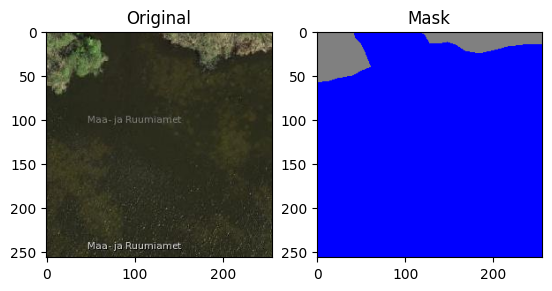

In [ ]:
img = Image.open(r'C:\Users\Виктор\Desktop\ML\kaggle\segmentation\kaggle_upload_public\train_images\narva_736023_6585841.jpg')

fig = plt.figure()

ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

ax1.imshow(img)
ax2.imshow(rgb_mask)

ax1.set_title('Original')
ax2.set_title('Mask')

Text(0.5, 1.0, 'Mask')

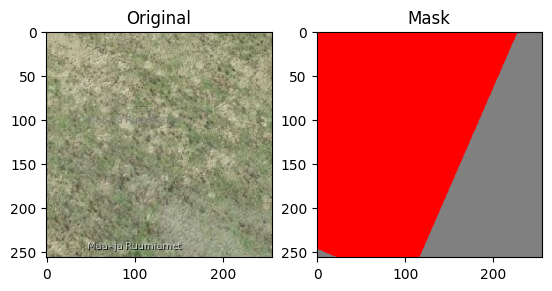

In [43]:
mask = Image.open(r'C:\Users\Виктор\Desktop\ML\kaggle\segmentation\kaggle_upload_public\train_masks\tartu_660496_6477596.png')
mask = np.array(mask)
rgb_mask = mask_to_rgb(mask)

img = Image.open(r'C:\Users\Виктор\Desktop\ML\kaggle\segmentation\kaggle_upload_public\train_images\tartu_660496_6477596.jpg')

fig = plt.figure()

ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

ax1.imshow(img)
ax2.imshow(rgb_mask)

ax1.set_title('Original')
ax2.set_title('Mask')

Проведя исследование данных, можно выделить следующие важные моменты:
1) Размер обучающей выборки 17 343 образов, тестовой выборки - 3057
1) В обучающей выборке и тестовой выборке присутствует дисбаланс классов (больше всего дорог - 35.8% от всех пикселей)
2) Есть неточности в целевых масках для обучающей выборки (папка train_masks), что может в дальнейшем негативно отразиться на качестве работе нейронной модели и ее оценке на независимых от обучающей выборки данных